# Práctica Estrategias de Vacunación en Redes <img src="http://www.ubu.es/sites/default/files/portal_page/images/logo_color_2l_dcha.jpg" height="75" align="right"/>

## Autores
> Roberto Iturralde Zarzo <br/>
> Rubén Castañeda Matute

## Introducción

<p>En esta práctica se analiza cómo reducir la transmisión de una enfermedad en una red de contactos vacunando individuos.<br/>Cada nodo representa una persona y cada enlace representa una relación entre ellas.</p>

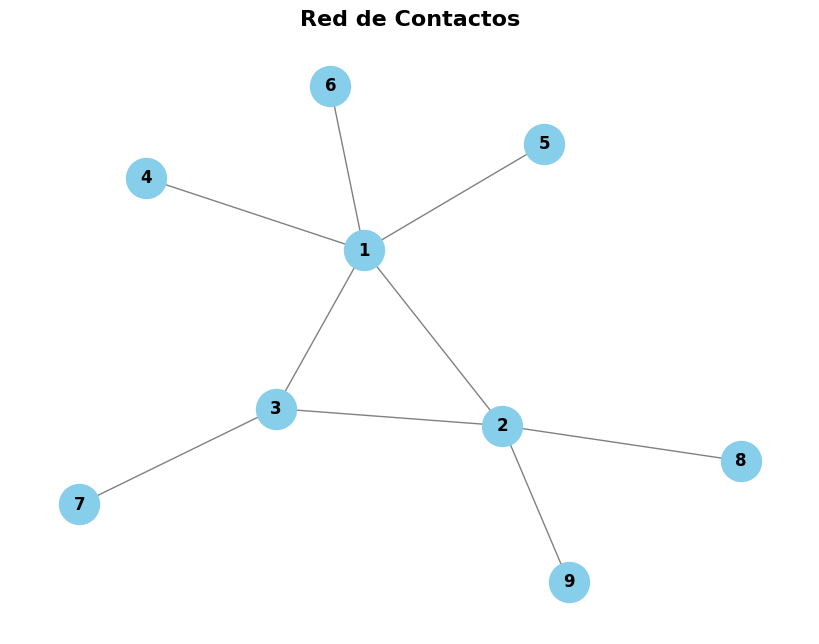

In [32]:
# Aquí hemos importado las librerias necesarias para la ejecución de este programa
import networkx as nx
import matplotlib.pyplot as plt

# Aquí definimos el grafo (Se usará en todo el notebook)
G = nx.Graph()
edges = [(1,2),(1,3),(1,4),(1,5),(1,6),
         (2,3),(2,8),(2,9),
         (3,7)]
G.add_edges_from(edges)

# Aquí definimos la visualización de la red
plt.figure(figsize=(8, 6))

# Aquí usamos un layout con semilla para que el grafo siempre se dibuje con la misma forma
pos = nx.spring_layout(G, seed=42) 

nx.draw(G, pos, with_labels=True, node_color='skyblue', 
        node_size=800, font_weight='bold', font_size=12, 
        edge_color='gray', linewidths=1.5)

plt.title("Red de Contactos", fontsize=16, fontweight='bold')
plt.show()

## 1. ¿A qué persona vacunarías si conoces la red?

Si conocemos la estructura completa de la red, la estrategia óptima para maximizar el número de relaciones inmunizadas es vacunar al nodo con el mayor grado (el que tiene el mayor número de vecinos).

En la red del ejercicio, el **nodo 1** es el que tiene más conexiones directas (grado 5, ya que está conectado a los nodos 2, 3, 4, 5 y 6). Por lo tanto, vacunar al nodo 1 inmuniza 5 relaciones, que es el máximo posible en este escenario. Le seguiría el nodo 2, con un grado de 4.

## 2. Simulación estrategia de vacunación aleatoria

Supongamos que desconocemos la estructura de la red. En esta estrategia elegimos una persona al azar uniformemente y la vacunamos. El número de relaciones inmunizadas será el grado del nodo elegido.

A continuación, simulamos esta estrategia con un número de repeticiones $T = 10000$ para estimar el valor esperado de relaciones inmunizadas.

In [33]:
# Aquí hemos importado las librerias necesarias para la ejecución de este programa
import random

# Aquí definimos los parametros iniciales
T = 10000
resultados_aleatorios = []

# Aquí simulamos T veces la elección de un nodo al azar
for _ in range(T):
    nodo = random.choice(list(G.nodes()))
    resultados_aleatorios.append(G.degree(nodo))

# Aquí calculamos el resultado esperado (media)
esperado_aleatorio = sum(resultados_aleatorios) / T

# Aquí imprimimos el resultado esperado
print(f'Valor esperado estrategia aleatoria (Simulación): {esperado_aleatorio:.4f}')

Valor esperado estrategia aleatoria (Simulación): 1.9959


## 3. Estrategia de vacunación aleatoria indirecta

Pasos de la estrategia:

1. Elegimos una persona al azar
2. Elegimos uno de sus vecinos
3. Vacunamos a ese vecino

Esto suele seleccionar nodos con más conexiones.

In [34]:
# Aquí definimos los parametros iniciales
resultados_indirectos = []

# Aquí simulamos T veces la estrategia indirecta
for _ in range(T):
    # Aquí elegimos un nodo al azar
    persona = random.choice(list(G.nodes()))
    vecinos = list(G.neighbors(persona))

    if len(vecinos) > 0:
        # Aquí elegimos un vecino al azar y obtenemos su grado
        vacunado = random.choice(vecinos)
        resultados_indirectos.append(G.degree(vacunado))

# Aquí calculamos el resultado esperado (media)
esperado_indirecto = sum(resultados_indirectos) / T

# Aquí imprimimos el resultado esperado
print(f'Valor esperado estrategia indirecta (Simulación): {esperado_indirecto:.4f}')

Valor esperado estrategia indirecta (Simulación): 3.7572


## 4. Comparación de estrategias

La **estrategia aleatoria indirecta** es significativamente mejor (con un valor esperado cercano a ~3.78) en comparación con la **estrategia aleatoria simple** (valor esperado cercano a ~2.00).

**¿Por qué sucede esto? La Paradoja de la Amistad**
La "Paradoja de la amistad" establece que, en promedio, los amigos de una persona tienen más amigos que ella misma. En el contexto de redes de contacto, esto significa que los nodos muy conectados ("hubs", como los nodos 1 y 2) aparecen de forma desproporcionada como vecinos de otros nodos.

* **En la estrategia aleatoria simple:** Todos los nodos tienen exactamente la misma probabilidad de ser elegidos (1/9). Hay muchos nodos periféricos (4, 5, 6, 7, 8, 9) que solo tienen grado 1. Elegir al azar tiene una alta probabilidad de caer en un nodo con pocas conexiones.
* **En la estrategia aleatoria indirecta:** El salto hacia el vecino actúa como un sesgo matemático hacia los hubs. Por ejemplo, si el paso 1 selecciona al nodo 4, 5 o 6, el paso 2 (elegir a su vecino) nos llevará ineludiblemente al nodo 1. De esta forma, utilizamos la red de nodos periféricos como un embudo para localizar y vacunar a los individuos más conectados de la red, maximizando la inmunización sin necesidad de conocer la estructura previamente.

## 5. Comparación con cálculos teóricos exactos

A continuación, importamos las funciones matemáticas desarrolladas en el script `assignment.py` para comprobar si el resultado de nuestras simulaciones de Montecarlo concuerda con los valores teóricos exactos (sin simulación).

In [35]:
# Aquí importamos el archivo assignment.py (El cuál debe estar en la misma carpeta que este Notebook)
try:
    from assignment import random_vaccine, indirect_random_vaccine

    # Aquí obtenemos los datos del archivo assignment.py
    teorico_aleatorio = random_vaccine(G)
    teorico_indirecto = indirect_random_vaccine(G)

    # Aquí hacemos la comparación de resultados
    print("--- Comparación de Resultados ---")
    print(f"Estrategia Aleatoria  -> Simulación: {esperado_aleatorio:.4f} | Teórico exacto: {teorico_aleatorio:.4f}")
    print(f"Estrategia Indirecta  -> Simulación: {esperado_indirecto:.4f} | Teórico exacto: {teorico_indirecto:.4f}")

except ImportError:
    # Aquí mostramos un error en caso de que no podamos leer el archivo assignment.py
    print("Nota: Para ver la comparación, asegúrate de tener el archivo 'assignment.py' con las funciones correspondientes en el mismo directorio.")

--- Comparación de Resultados ---
Estrategia Aleatoria  -> Simulación: 1.9959 | Teórico exacto: 2.0000
Estrategia Indirecta  -> Simulación: 3.7572 | Teórico exacto: 3.7593
